# 01 Exploratory Data Analysis (EDA) - Email Spam Audit

This notebook is a formal data quality audit of the `email_spam.csv` dataset. We explore the structural "dirt" and visualize the noise that would otherwise break our machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style='whitegrid', palette='muted')
%matplotlib inline

### Step 1: Loading & Casing Normalization
**Action**: Load the CSV and lowercase all headers.
**Why?**: Real-world datasets often have inconsistent casing. By standardizing to `snake_case` now, we avoid `KeyError` exceptions later in the pipeline.

In [2]:
df = pd.read_csv('../_data/email_spam.csv')
df.columns = [col.lower().replace('-', '_').replace(' ', '_') for col in df.columns]
print("Standardized Headers:", df.columns.tolist())

Standardized Headers: ['email_id', 'sender_email', 'subject_line', 'message_content', 'date', 'priority', 'attachments', 'links_count', 'target_label', 'version']


### Step 2: Visualizing Label Chaos
**Action**: Plot the distribution of the `target_label`.
**Why?**: We need to see how many different strings represent 'Spam'. If we see `spam`, `SPAM`, and `1`, we know we must perform categorical normalization.

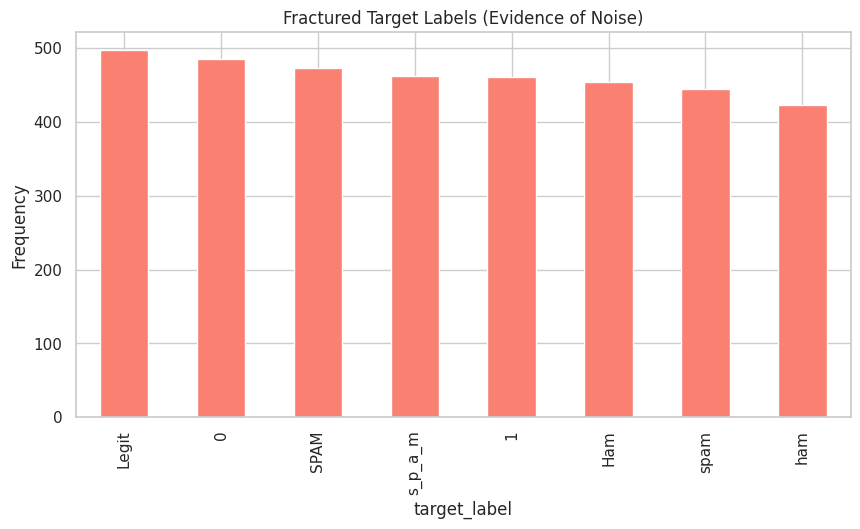

In [3]:
plt.figure(figsize=(10, 5))
df['target_label'].value_counts().plot(kind='bar', color='salmon')
plt.title('Fractured Target Labels (Evidence of Noise)')
plt.ylabel('Frequency')
plt.show()

### Step 3: Missing Value Heatmap
**Action**: Visualize null values across all features.
**Why?**: We need to identify if features like `priority` or `attachments` have empty values that require imputation before they can be used as model inputs.

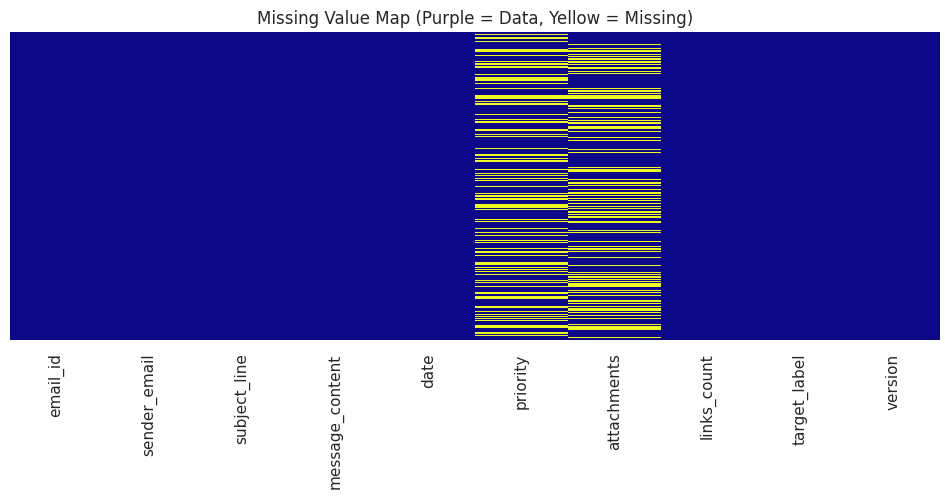

In [4]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='plasma')
plt.title('Missing Value Map (Purple = Data, Yellow = Missing)')
plt.show()

### Step 4: Text Noise (HTML Analysis)
**Action**: Compare message lengths.
**Why?**: HTML tags add character length without adding semantic value. This visualization justifies our need for a Regex-based HTML stripper.

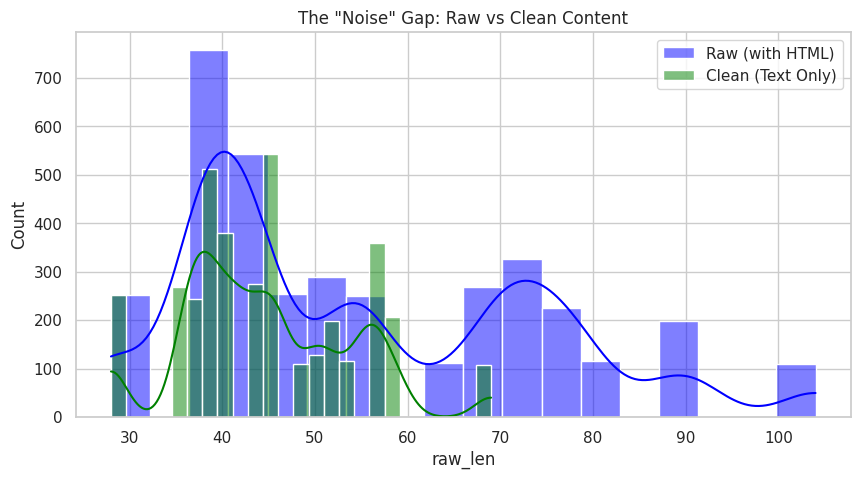

In [5]:
df['raw_len'] = df['message_content'].str.len()
df['clean_len'] = df['message_content'].apply(lambda x: len(re.sub('<.*?>', '', str(x))))

plt.figure(figsize=(10, 5))
sns.histplot(df['raw_len'], color='blue', label='Raw (with HTML)', kde=True)
sns.histplot(df['clean_len'], color='green', label='Clean (Text Only)', kde=True)
plt.title('The "Noise" Gap: Raw vs Clean Content')
plt.legend()
plt.show()

## Preprocessing Roadmap
1. **Deduplicate**: Remove 100 repeats.
2. **Map Labels**: Convert all spam variants to `1`.
3. **Regex Strip**: Remove HTML from `message_content`.
4. **Vectorize**: Use TF-IDF to turn cleaned text into numbers for the model.